Matplotlib is building the font cache; this may take a moment.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000509 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1053
[LightGBM] [Info] Number of data points in the train set: 3528, number of used features: 12
[LightGBM] [Info] Start training from score 186.359977
--- MODEL BAŞARI METRİKLERİ ---
Root Mean Squared Error (RMSE): 64.12
R² Skoru (Açıklayıcılık Oranı): %70.26


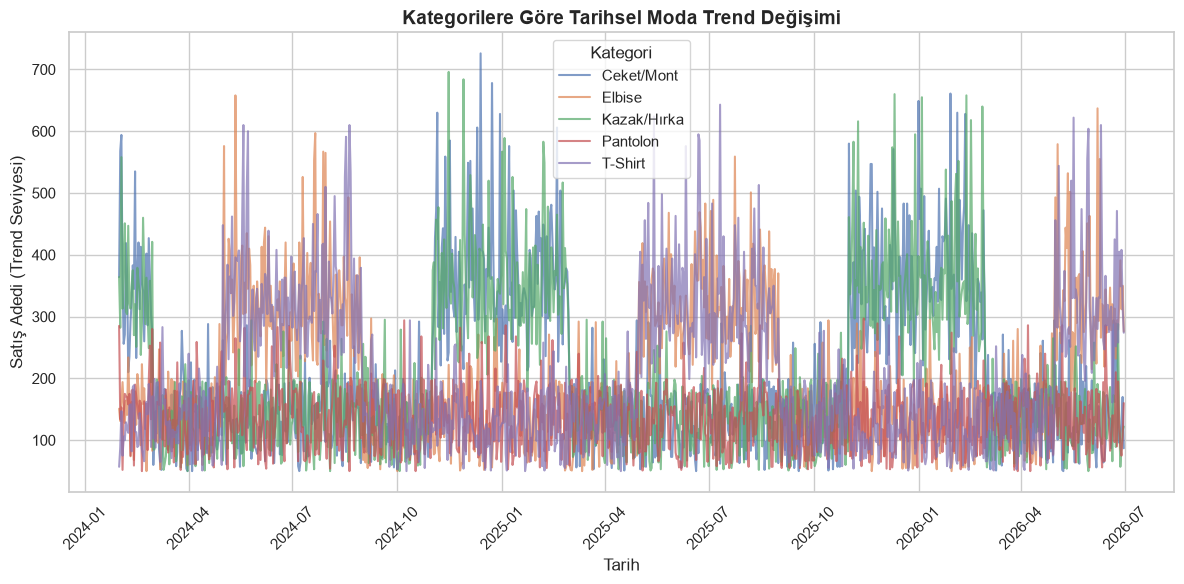

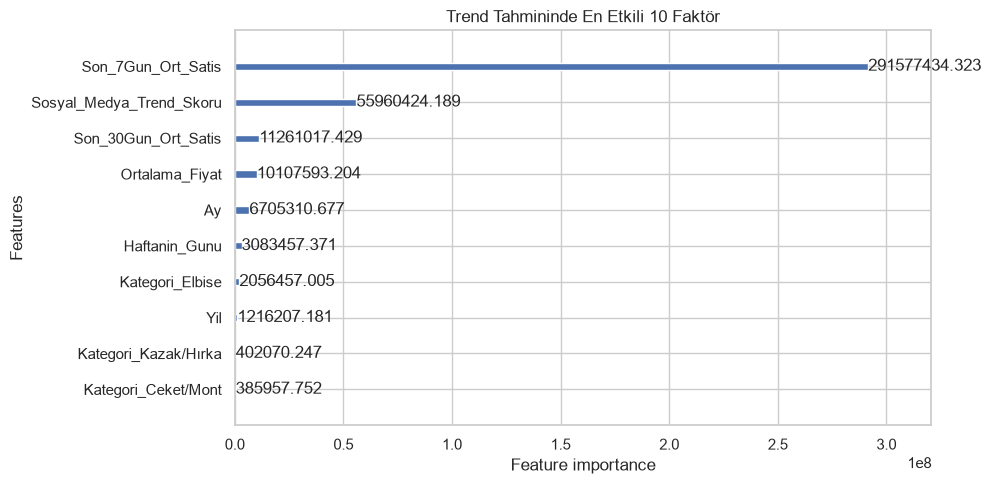

In [ ]:



# 1. KÜTÜPHANELERİN YÜKLENMESİ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb 
import warnings
warnings.filterwarnings('ignore')

# Seaborn stil ayarları
sns.set_theme(style="whitegrid")

# ==========================================
# 2. SENTETİK MODA SATIŞ & TREND VERİSİ OLUŞTURMA
# ==========================================
np.random.seed(42)
dates = pd.date_range(start="2024-01-01", end="2026-06-30", freq="D")
categories = ['Elbise', 'T-Shirt', 'Kazak/Hırka', 'Ceket/Mont', 'Pantolon']

data = []
for date in dates:
    for cat in categories:
        # Sezonluk ve trend etkileri simüle etme
        base_sales = np.random.randint(50, 200)
        
        # Yaz sezonu etkisi (Elbise ve T-Shirt artar)
        if date.month in [5, 6, 7, 8] and cat in ['Elbise', 'T-Shirt']:
            base_sales += np.random.randint(100, 250)
            
        # Kış sezonu etkisi (Kazak ve Ceket artar)
        if date.month in [11, 12, 1, 2] and cat in ['Kazak/Hırka', 'Ceket/Mont']:
            base_sales += np.random.randint(120, 300)
            
        # Rastgele sosyal medya / trend patlaması (Trend Spikes)
        trend_score = np.random.uniform(1.0, 10.0)
        if trend_score > 8.5:
            base_sales = int(base_sales * 1.5)

        price = np.random.uniform(250, 1500)
        
        data.append({
            'Tarih': date,
            'Kategori': cat,
            'Satis_Adedi': base_sales,
            'Ortalama_Fiyat': round(price, 2),
            'Sosyal_Medya_Trend_Skoru': round(trend_score, 2)
        })

df = pd.DataFrame(data)

# ==========================================
# 3. ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
# ==========================================
df['Yil'] = df['Tarih'].dt.year
df['Ay'] = df['Tarih'].dt.month
df['Haftanin_Gunu'] = df['Tarih'].dt.dayofweek
df['Hafta_Sonu_Mu'] = df['Haftanin_Gunu'].apply(lambda x: 1 if x >= 5 else 0)

# Trend İvme Özellikleri (Lag & Rolling Features)
df = df.sort_values(by=['Kategori', 'Tarih'])

# Son 7 ve 30 günlük ortalama satışlar (Trend Trendi)
df['Son_7Gun_Ort_Satis'] = df.groupby('Kategori')['Satis_Adedi'].transform(lambda x: x.shift(1).rolling(7).mean())
df['Son_30Gun_Ort_Satis'] = df.groupby('Kategori')['Satis_Adedi'].transform(lambda x: x.shift(1).rolling(30).mean())

# Eksik verileri temizleme
df.dropna(inplace=True)

# Categorical verileri dönüştürme (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['Kategori'], drop_first=False)

# ==========================================
# 4. MODEL EĞİTİMİ (LIGHTGBM REGRESSOR)
# ==========================================
X = df_encoded.drop(columns=['Tarih', 'Satis_Adedi'])
y = df_encoded['Satis_Adedi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

# Tahminler
y_pred = model.predict(X_test)

# Metrikler
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- MODEL BAŞARI METRİKLERİ ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Skoru (Açıklayıcılık Oranı): %{r2*100:.2f}")

# ==========================================
# 5. GÖRSELLEŞTİRME & TREND ANALİZİ
# ==========================================
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Tarih', y='Satis_Adedi', hue='Kategori', alpha=0.7)
plt.title('Kategorilere Göre Tarihsel Moda Trend Değişimi', fontsize=14, fontweight='bold')
plt.xlabel('Tarih')
plt.ylabel('Satış Adedi (Trend Seviyesi)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# En Önemli Trend Belirleyici Değişkenler
lgb.plot_importance(model, max_num_features=10, importance_type='gain', figsize=(10, 5), title='Trend Tahmininde En Etkili 10 Faktör')
plt.tight_layout()
plt.show()